# Python for Data Analysis Notebook

This notebook is the runnable alternative to the HTML guide. Use it cell by cell to practice Python fundamentals, pandas workflows, visualization, and project-style analysis on realistic datasets.

Datasets in this workspace:

- `python-sales.csv`
- `python-users.csv`
- `python-transactions.csv`
- `python-products.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

## 1. Python Fundamentals

This section covers variables, data types, operators, conditionals, loops, and functions.


In [2]:
orders = 120
avg_value = 25.75
country = 'India'
regions = ['North', 'South', 'East']
profile = {'user_id': 1, 'country': 'US'}
unique_regions = {'US', 'CA', 'IN'}

print(orders, avg_value, country)
print(regions)
print(profile)
print(unique_regions)

revenue = 4 * 19.99
print(revenue)

score = 82
if score >= 90:
    grade = 'A'
elif score >= 80:
    grade = 'B'
else:
    grade = 'C'
print(grade)

def net_revenue(quantity, unit_price, discount=0):
    return quantity * unit_price * (1 - discount)

print(net_revenue(10, 25.0, 0.1))

120 25.75 India
['North', 'South', 'East']
{'user_id': 1, 'country': 'US'}
{'CA', 'US', 'IN'}
79.96
B
225.0


## 2. Load and Inspect Data

Use pandas to load the sample sales and users data, then inspect the shape, columns, and types.


In [3]:
sales = pd.read_csv('python-sales.csv')
users = pd.read_csv('python-users.csv')
transactions = pd.read_csv('python-transactions.csv')
products = pd.read_csv('python-products.csv')

display(sales.head())
display(users.head())
sales.info()
print(sales.describe())

,order_id,order_date,user_id,product_id,quantity,unit_price,discount,region
0,1001,2024-06-01,1,101,2,120.0,0.05,North
1,1002,2024-06-03,2,102,4,49.0,0.00,South
2,1003,2024-06-05,3,103,1,299.0,0.10,East
3,1004,2024-06-07,4,104,10,19.0,0.00,West
4,1005,2024-06-10,5,105,1,499.0,0.08,North


,user_id,signup_date,country,acquisition_channel,age,plan_type
0,1,2024-01-05,United States,Organic,34,Pro
1,2,2024-01-11,Canada,Paid,28,Free
2,3,2024-02-02,United Kingdom,Organic,41,Pro
3,4,2024-02-15,India,Referral,25,Free
4,5,2024-03-01,United States,Paid,38,Enterprise


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    10 non-null     int64  
 1   order_date  10 non-null     object 
 2   user_id     10 non-null     int64  
 3   product_id  10 non-null     int64  
 4   quantity    10 non-null     int64  
 5   unit_price  10 non-null     float64
 6   discount    10 non-null     float64
 7   region      10 non-null     object 
dtypes: float64(2), int64(4), object(2)
memory usage: 772.0+ bytes
         order_id    user_id  product_id   quantity  unit_price   discount
count    10.00000  10.000000   10.000000  10.000000   10.000000  10.000000
mean   1005.50000   3.000000  103.000000   3.200000  197.200000   0.043000
std       3.02765   1.490712    1.490712   2.859681  189.223442   0.044981
min    1001.00000   1.000000  101.000000   1.000000   19.000000   0.000000
25%    1003.25000   2.000000  102.000000   1.25

## 3. NumPy Basics

NumPy is useful for vectorized numeric operations and fast array calculations.


In [4]:
prices = np.array([10, 20, 30, 40])
discount = 0.1
net_prices = prices * (1 - discount)

print('prices:', prices)
print('net_prices:', net_prices)
print('mean:', np.mean(net_prices))
print('sum:', np.sum(net_prices))

prices: [10 20 30 40]
net_prices: [ 9. 18. 27. 36.]
mean: 22.5
sum: 90.0


## 4. Pandas Data Cleaning

This is one of the most important analyst workflows: remove duplicates, fix data types, clean strings, and create analysis-ready columns.


In [5]:
sales_clean = sales.copy()
sales_clean = sales_clean.drop_duplicates()
sales_clean['order_date'] = pd.to_datetime(sales_clean['order_date'])
sales_clean['region'] = sales_clean['region'].str.strip().str.title()
sales_clean['net_amount'] = sales_clean['quantity'] * sales_clean['unit_price'] * (1 - sales_clean['discount'])

display(sales_clean.head())
print(sales_clean.dtypes)

,order_id,order_date,user_id,product_id,quantity,unit_price,discount,region,net_amount
0,1001,2024-06-01,1,101,2,120.0,0.05,North,228.00
1,1002,2024-06-03,2,102,4,49.0,0.00,South,196.00
2,1003,2024-06-05,3,103,1,299.0,0.10,East,269.10
3,1004,2024-06-07,4,104,10,19.0,0.00,West,190.00
4,1005,2024-06-10,5,105,1,499.0,0.08,North,459.08


order_id               int64
order_date    datetime64[ns]
user_id                int64
product_id             int64
quantity               int64
unit_price           float64
discount             float64
region                object
net_amount           float64
dtype: object


In [6]:
# Missing value handling example
sales_clean['discount'] = sales_clean['discount'].fillna(0)

# Filtering example
high_value = sales_clean[(sales_clean['net_amount'] > 100) & (sales_clean['region'] == 'North')]
display(high_value)

,order_id,order_date,user_id,product_id,quantity,unit_price,discount,region,net_amount
0,1001,2024-06-01,1,101,2,120.0,0.05,North,228.00
4,1005,2024-06-10,5,105,1,499.0,0.08,North,459.08
5,1006,2024-06-12,1,103,2,299.0,0.05,North,568.10
9,1010,2024-07-08,5,104,6,19.0,0.03,North,110.58


## 5. Aggregation and Grouping

Groupby and pivot tables are core patterns for summary reporting.


In [7]:
region_summary = (
    sales_clean.groupby('region')
    .agg(total_orders=('order_id', 'count'),
         total_revenue=('net_amount', 'sum'),
         avg_revenue=('net_amount', 'mean'))
    .reset_index()
)
display(region_summary)

pivot = pd.pivot_table(
    sales_clean,
    index='region',
    columns='product_id',
    values='net_amount',
    aggfunc='sum',
    fill_value=0
)
display(pivot)

,region,total_orders,total_revenue,avg_revenue
0,East,2,708.22,354.11
1,North,4,1365.76,341.44
2,South,2,556.00,278.00
3,West,2,288.00,144.00


product_id,101,102,103,104,105
region,,,,,
East,0.0,0.0,269.1,0.00,439.12
North,228.0,0.0,568.1,110.58,459.08
South,360.0,196.0,0.0,0.00,0.00
West,0.0,98.0,0.0,190.00,0.00


## 6. Data Visualization

Use Matplotlib for control and Seaborn for fast statistical visualizations.


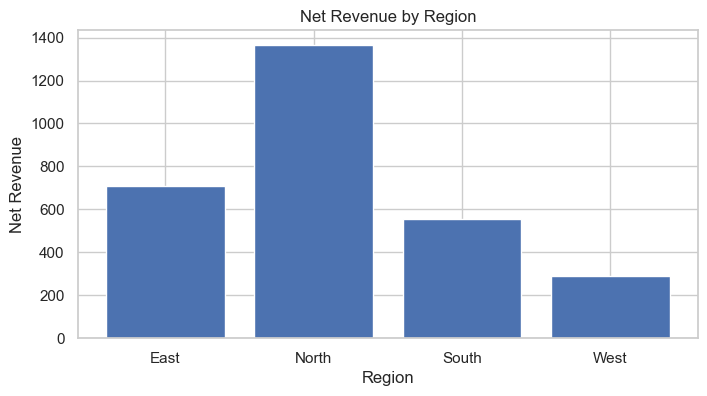

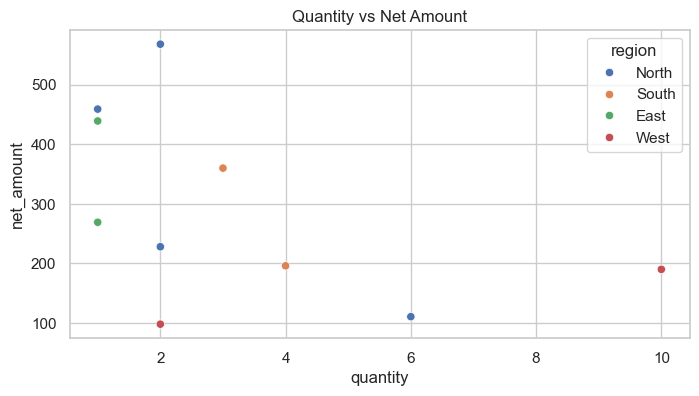

In [8]:
sales_by_region = sales_clean.groupby('region', as_index=False)['net_amount'].sum()

plt.figure(figsize=(8, 4))
plt.bar(sales_by_region['region'], sales_by_region['net_amount'])
plt.title('Net Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Net Revenue')
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=sales_clean, x='quantity', y='net_amount', hue='region')
plt.title('Quantity vs Net Amount')
plt.show()

## 7. Advanced Pandas and Time Series

Join, merge, resample, and rolling calculations are common in real analyst workflows.


In [9]:
merged = sales_clean.merge(users, on='user_id', how='left')
merged = merged.merge(products, on='product_id', how='left')
display(merged.head())

merged['order_date'] = pd.to_datetime(merged['order_date'])
monthly = merged.set_index('order_date')['net_amount'].resample('M').sum().reset_index()
monthly['rolling_3'] = monthly['net_amount'].rolling(3).mean()
display(monthly)

,order_id,order_date,user_id,product_id,quantity,unit_price,discount,region,net_amount,signup_date,country,acquisition_channel,age,plan_type,product_name,category,list_price,launch_date
0,1001,2024-06-01,1,101,2,120.0,0.05,North,228.00,2024-01-05,United States,Organic,34,Pro,Wireless Headphones,Electronics,120.0,2024-01-01
1,1002,2024-06-03,2,102,4,49.0,0.00,South,196.00,2024-01-11,Canada,Paid,28,Free,Notebook,Stationery,49.0,2024-01-15
2,1003,2024-06-05,3,103,1,299.0,0.10,East,269.10,2024-02-02,United Kingdom,Organic,41,Pro,Smart Speaker,Electronics,299.0,2024-02-10
3,1004,2024-06-07,4,104,10,19.0,0.00,West,190.00,2024-02-15,India,Referral,25,Free,USB Cable,Accessories,19.0,2024-02-20
4,1005,2024-06-10,5,105,1,499.0,0.08,North,459.08,2024-03-01,United States,Paid,38,Enterprise,Mechanical Keyboard,Electronics,499.0,2024-03-05


C:\Users\HP\AppData\Local\Temp\ipykernel_3372\2667094106.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = merged.set_index('order_date')['net_amount'].resample('M').sum().reset_index()


,order_date,net_amount,rolling_3
0,2024-06-30,1910.28,NaN
1,2024-07-31,1007.70,NaN


## 8. Expert-Level Analyses

These patterns show how analysts think in real business problems.


In [10]:
# Cohort month
merged['signup_date'] = pd.to_datetime(merged['signup_date'])
merged['cohort_month'] = merged.groupby('user_id')['signup_date'].transform('min').dt.to_period('M')
merged['order_month'] = merged['order_date'].dt.to_period('M')

# Simple retention-style cross-tab
retention = pd.crosstab(merged['cohort_month'], merged['order_month'])
display(retention)

# Funnel-style example
funnel = transactions.groupby('status')['transaction_id'].count().reset_index(name='count')
display(funnel)

order_month,2024-06,2024-07
cohort_month,,
2024-01,3,1
2024-02,2,2
2024-03,1,1


,status,count
0,Pending,1
1,Settled,9


In [12]:
# Feature engineering example
merged['basket_size'] = merged['quantity'] * merged['unit_price']
merged['high_value_order'] = (merged['basket_size'] > 200).astype(int)
display(merged[['order_id', 'basket_size', 'high_value_order']].head())

# Basic classification-ready dataset
model_df = merged[['basket_size', 'discount', 'high_value_order']].dropna()
display(model_df.head())

,order_id,basket_size,high_value_order
0,1001,240.0,1
1,1002,196.0,0
2,1003,299.0,1
3,1004,190.0,0
4,1005,499.0,1


,basket_size,discount,high_value_order
0,240.0,0.05,1
1,196.0,0.00,0
2,299.0,0.10,1
3,190.0,0.00,0
4,499.0,0.08,1


## 9. Real-World Projects

Use these project patterns for portfolio work and job interviews.


In [13]:
# Sales project output
sales_project = (
    merged.groupby('region')
    .agg(total_revenue=('net_amount', 'sum'),
         orders=('order_id', 'count'),
         avg_order_value=('net_amount', 'mean'))
    .reset_index()
)
display(sales_project)

# Customer segmentation output
customer_segment = (
    merged.groupby('user_id', as_index=False)['net_amount'].sum()
)
customer_segment['segment'] = pd.qcut(customer_segment['net_amount'], q=3, labels=['Low', 'Medium', 'High'])
display(customer_segment)

,region,total_revenue,orders,avg_order_value
0,East,708.22,2,354.11
1,North,1365.76,4,341.44
2,South,556.00,2,278.00
3,West,288.00,2,144.00


,user_id,net_amount,segment
0,1,796.10,High
1,2,556.00,Low
2,3,708.22,High
3,4,288.00,Low
4,5,569.66,Medium


## 10. Python with SQL, Excel, Jupyter, and AI

Python often sits between databases, spreadsheets, and BI workflows. It also works well with AI-assisted coding.


In [14]:
# Example of exporting analysis-ready output
sales_project.to_csv('sales_project_summary.csv', index=False)
print('Exported sales_project_summary.csv')

# Example AI prompt template for your workflow
prompt = 'Write pandas code to clean sales data, create monthly revenue, and highlight outliers.'
print(prompt)

Exported sales_project_summary.csv
Write pandas code to clean sales data, create monthly revenue, and highlight outliers.


## 11. Bonus: Mastery Thinking

Strong analysts use Python to make workflows repeatable, auditable, and business-friendly. The output should be reliable enough for dashboards, reporting, or downstream ML use.
